<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/Sba_Loan_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SBA Loan Default Prediction

**STEPS PERFORMED BRIEF OVERVIEW**
1. **Data Loading and Initial
Inspection**: *We started by loading the Sba loan.csv file into a pandas DataFrame and performing initial checks.*
2. **Data Cleaning**: *We cleaned the dataset by dropping irrelevant columns such as BankState, ApprovalFY, and New. We also handled missing values by dropping rows with NaN in NewExist, RevLineCr, and LowDoc, and removed duplicate rows.*
3. **Label Encoding**: *Categorical features like RevLineCr, LowDoc, and MIS_Status were converted into numerical representations (0s and 1s) for model compatibility.*
4. **EDA - Data Exploration and Visualization**: *We explored the dataset's descriptive statistics*
5. **Outliers Detection** - visualized the distributions of numerical columns using box plots.
6. **Multicollinearity** - *A correlation matrix was also generated to understand relationships between features*.
7. **Hypothesis Testing**: *We conducted several hypothesis tests to investigate specific relationships.*
8. **Machine Learning Model (Logistic Regression)**: *defined the target variable (MIS_Status). We then split the data into training and testing sets. A Logistic Regression model was iteratively built using statsmodels, starting with all significant features and then progressively removing features with high p-values.*
9. **Model Diagnostics**: *The final Logistic Regression model was evaluated using:
A Confusion Matrix and
An ROC Curve and AUC Score.*

##Data Loading and Initial Inspection

In [1]:
import pandas as pd

df = pd.read_csv('/content/Sba loan.csv')
display(df.head())

,BankState,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
0,CA,2001,36,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0,0.5,0
1,CA,2001,56,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0,0.5,1
2,CA,2001,36,10,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0,0.5,0
3,CA,2003,36,6,1.0,0,0,0,Y,N,P I F,0,50000,25000,0,0,0.5,0
4,CO,2006,240,65,1.0,3,65,1,0,N,P I F,0,343000,343000,0,1,1.0,0


In [35]:
df.tail()

,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
2097,60,5,2.0,0,5,1,0,0,0,0,150000,75000,1,0,0.50,0
2098,300,4,1.0,0,0,0,0,0,0,0,99000,79200,0,1,0.80,0
2099,84,2,1.0,0,0,0,0,0,0,0,50000,40000,0,0,0.80,0
2100,120,3,1.0,0,0,0,0,0,0,0,500000,375000,0,0,0.75,0
2101,60,4,1.0,0,0,0,1,0,0,0,35000,17500,0,0,0.50,0


## **Data Cleaning**

In [4]:
df = df.drop(columns=['BankState', 'ApprovalFY','New'])
display(df.head())

,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,RealEstate,Portion,Recession
0,36,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0.5,0
1,56,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0.5,1
2,36,10,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0.5,0
3,36,6,1.0,0,0,0,Y,N,P I F,0,50000,25000,0,0.5,0
4,240,65,1.0,3,65,1,0,N,P I F,0,343000,343000,1,1.0,0


Dropping Bank State , ApprovalFy ,New because they are irrelevant

In [5]:
print(df.isnull().sum())

Term            0
NoEmp           0
NewExist        1
CreateJob       0
RetainedJob     0
UrbanRural      0
RevLineCr       2
LowDoc          3
MIS_Status      0
ChgOffPrinGr    0
GrAppv          0
SBA_Appv        0
RealEstate      0
Portion         0
Recession       0
dtype: int64


We have null values in Newexist ,revlinecr and Lowdoc . we will remove them directly.

In [6]:
df.dropna(subset=['NewExist', 'RevLineCr', 'LowDoc'], inplace=True)
print(df.isnull().sum())

Term            0
NoEmp           0
NewExist        0
CreateJob       0
RetainedJob     0
UrbanRural      0
RevLineCr       0
LowDoc          0
MIS_Status      0
ChgOffPrinGr    0
GrAppv          0
SBA_Appv        0
RealEstate      0
Portion         0
Recession       0
dtype: int64


Null Values Treated

In [7]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 95


Checking for Duplicates , we will remove them

In [8]:
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows after removal: 0


## Label Encoding


we have Categorical features like RevLineCr, LowDoc, and MIS_Status(target Variable ) converting them  into numerical representations (0s and 1s) for model compatibility.

In [9]:
# Reload the original DataFrame to undo the corrupted state
df = pd.read_csv('/content/Sba loan.csv')

# Re-apply previous cleaning steps
df = df.drop(columns=['BankState', 'ApprovalFY'])
df.dropna(subset=['NewExist', 'RevLineCr', 'LowDoc'], inplace=True)
df.drop_duplicates(inplace=True)

print('Original unique values for categorical columns after reload and clean:')
print(f"RevLineCr: {df['RevLineCr'].unique()}")
print(f"LowDoc: {df['LowDoc'].unique()}")
print(f"MIS_Status: {df['MIS_Status'].unique()}")

# Correctly map categorical values to numerical representations
df['RevLineCr'] = df['RevLineCr'].map({'0': 0, 'N': 0, 'T': 1, 'Y': 1})
df['LowDoc'] = df['LowDoc'].map({'N': 0, 'S': 0, 'A': 0, '0': 0, 'Y': 1})
df['MIS_Status'] = df['MIS_Status'].map({'P I F': 0, 'CHGOFF': 1})

print('\nEncoded unique values for categorical columns after corrected mapping:')
print(f"RevLineCr: {df['RevLineCr'].unique()}")
print(f"LowDoc: {df['LowDoc'].unique()}")
print(f"MIS_Status: {df['MIS_Status'].unique()}")

display(df.head())

Original unique values for categorical columns after reload and clean:
RevLineCr: ['Y' '0' 'N' 'T']
LowDoc: ['N' 'Y' 'S' 'A' '0']
MIS_Status: ['P I F' 'CHGOFF']

Encoded unique values for categorical columns after corrected mapping:
RevLineCr: [1 0]
LowDoc: [0 1]
MIS_Status: [0 1]


,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
0,36,1,1.0,0,0,0,1,0,0,0,30000,15000,0,0,0.5,0
1,56,1,1.0,0,0,0,1,0,0,0,30000,15000,0,0,0.5,1
2,36,10,1.0,0,0,0,1,0,0,0,30000,15000,0,0,0.5,0
3,36,6,1.0,0,0,0,1,0,0,0,50000,25000,0,0,0.5,0
4,240,65,1.0,3,65,1,0,0,0,0,343000,343000,0,1,1.0,0


Now all the columns are succesfully encoded


## **EDA - Exploratory Data Analysis**

Checking for Descriptive statistics


In [10]:
display(df.describe())

,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
count,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2.001000e+03,2.001000e+03,2.001000e+03,2001.000000,2001.000000,2001.000000,2001.000000
mean,129.063968,10.543228,1.154423,2.671664,5.995502,0.947526,0.350325,0.020490,0.342329,2.103462e+04,2.427302e+05,1.974819e+05,0.154923,0.287856,0.678789,0.071964
std,95.532695,35.209321,0.362825,8.190033,19.428600,0.419220,0.477191,0.141704,0.474608,7.717702e+04,3.489372e+05,3.036478e+05,0.361921,0.452877,0.187041,0.258493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,4.500000e+03,2.250000e+03,0.000000,0.000000,0.296770,0.000000
25%,60.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,3.000000e+04,1.700000e+04,0.000000,0.000000,0.500000,0.000000
50%,84.000000,4.000000,1.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,8.000000e+04,5.000000e+04,0.000000,0.000000,0.750000,0.000000
75%,240.000000,8.000000,1.000000,2.000000,5.000000,1.000000,1.000000,0.000000,1.000000,1.911900e+04,3.120000e+05,2.512500e+05,0.000000,1.000000,0.850000,0.000000
max,306.000000,650.000000,2.000000,130.000000,535.000000,2.000000,1.000000,1.000000,1.000000,1.509550e+06,2.350000e+06,2.115000e+06,1.000000,1.000000,1.000000,1.000000


We can infer from this
* **Loan Size and Duration:** Most loans are around **$80,000** and last roughly **7 to 10 years**, though a few very large, 20-year real estate loans pull the averages higher.
* **Company Size:** The typical business is very small, usually having only **4 employees**, yet they manage to retain about **6 jobs** on average.
* **Safety Net:** The SBA guarantees a large chunk of the risk, covering an average of **68%** of the total loan amount for these lenders.

## **Outlier Detection**

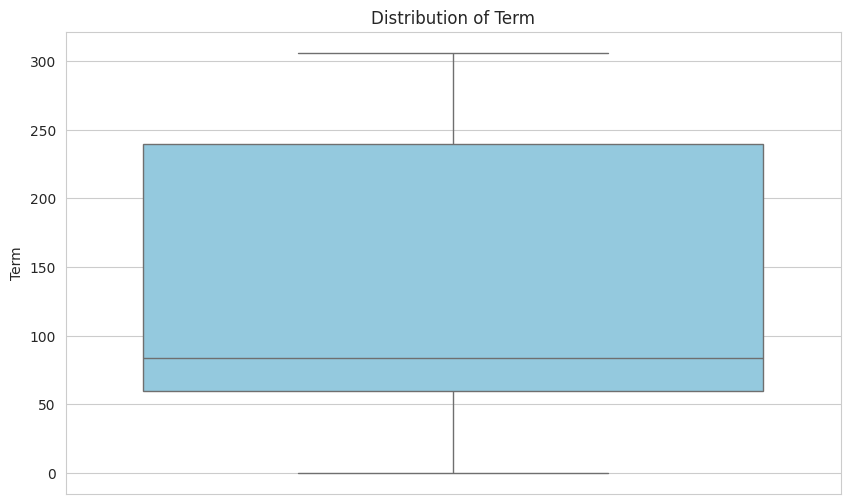

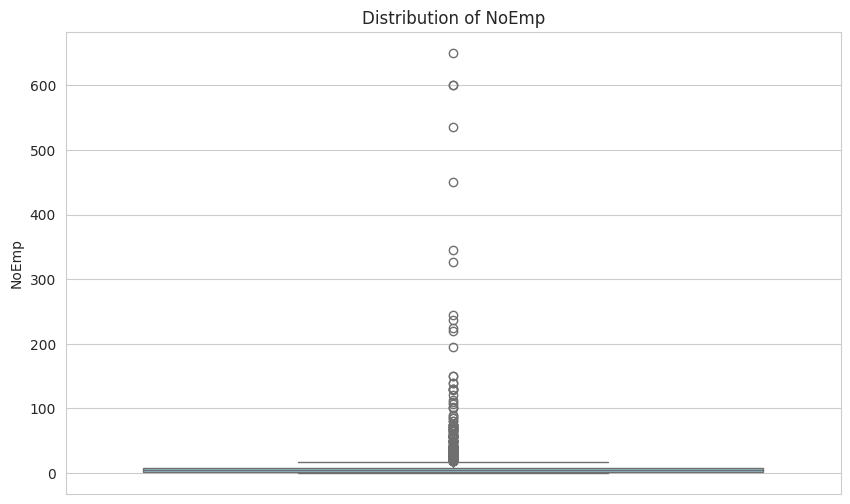

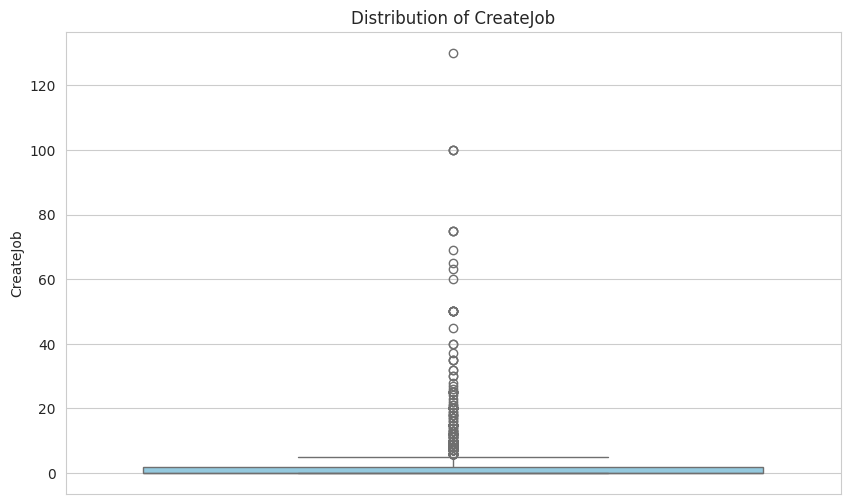

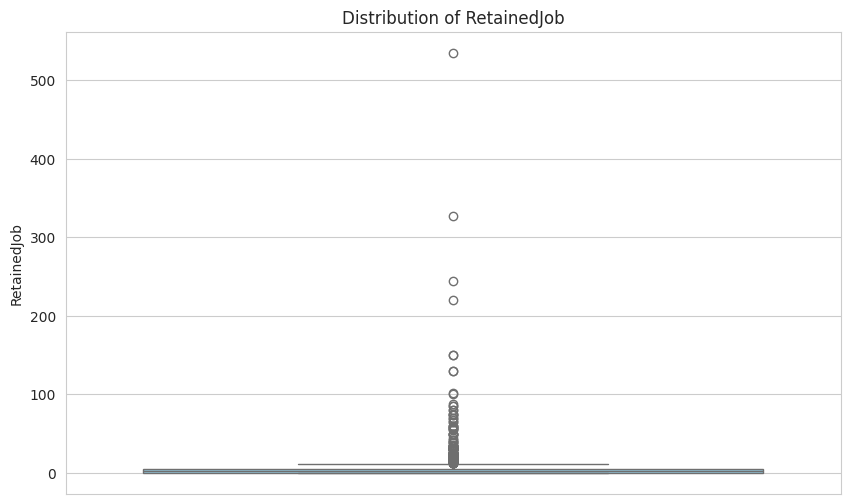

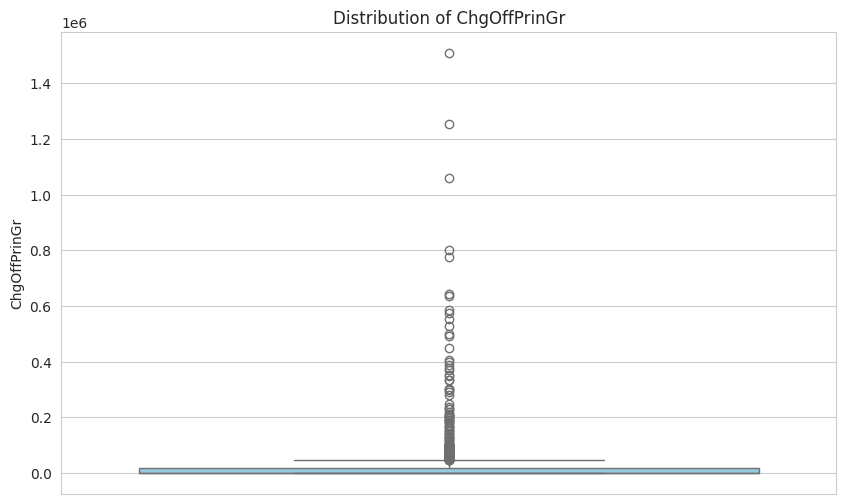

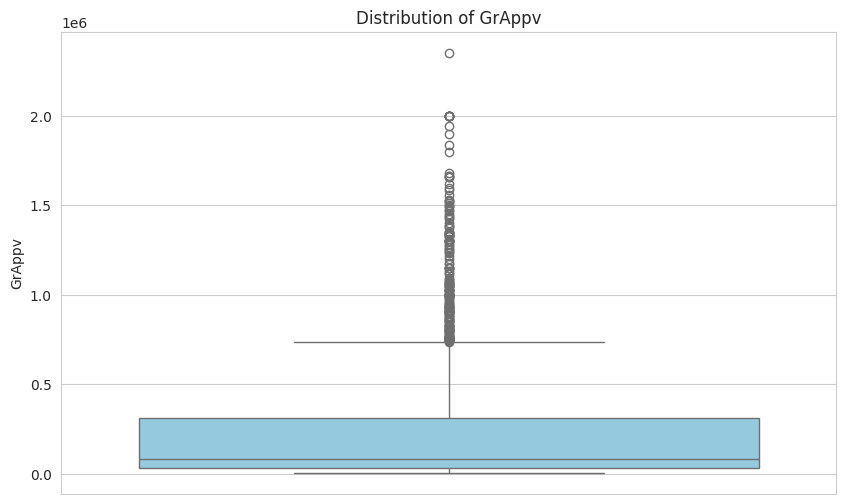

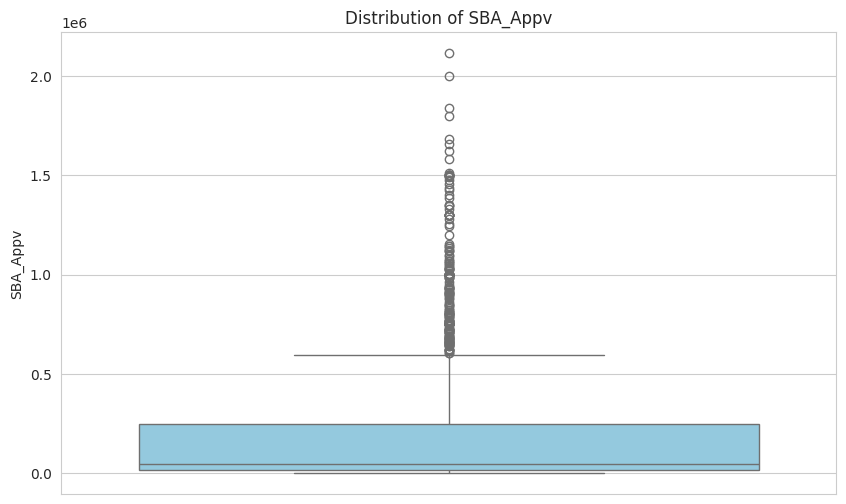

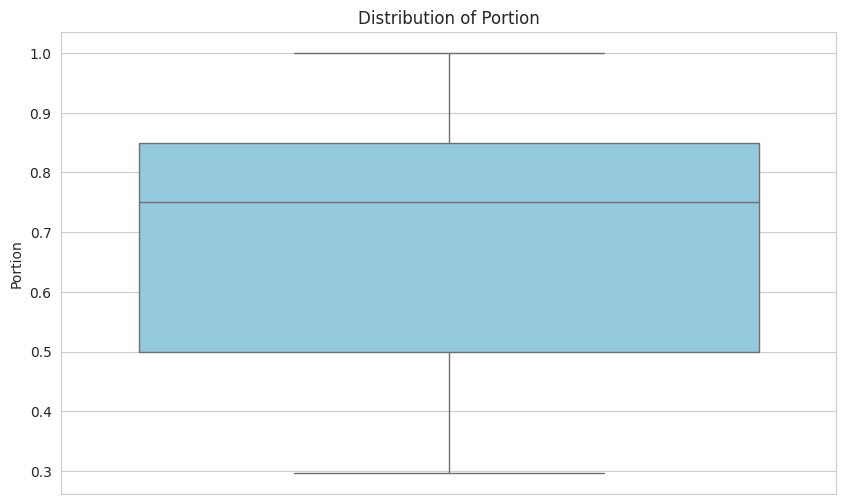

All relevant numerical box plots generated.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# Get numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Define columns that are conceptually categorical/binary but are of numerical type
# and thus not suitable for typical outlier detection via box plots
excluded_cols = [
    'MIS_Status',
    'NewExist',
    'UrbanRural',
    'RevLineCr',
    'LowDoc',
    'New',
    'RealEstate',
    'Recession'
]

# Filter out the excluded columns to get only continuous numerical features
numerical_cols_for_outliers = [col for col in numerical_cols if col not in excluded_cols]

if not numerical_cols_for_outliers:
    print("No continuous numerical columns found for outlier detection after filtering.")
else:
    for col in numerical_cols_for_outliers:
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=col, data=df, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.ylabel(col)
        plt.show()

    print("All relevant numerical box plots generated.")

There are outliers in data

##Correlation Matrix

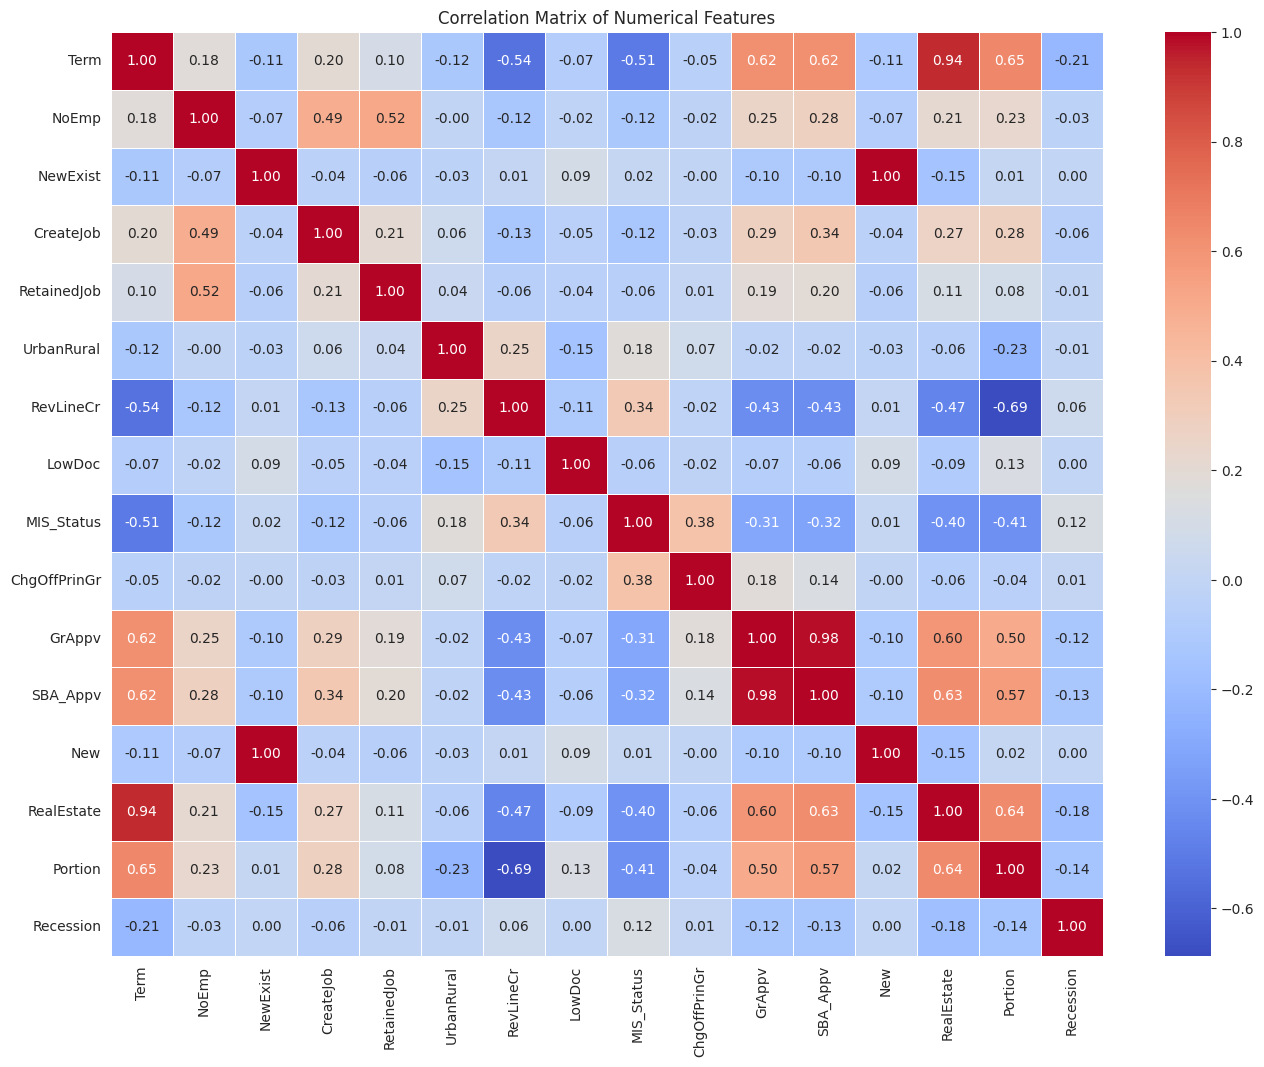

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

My inferences from this correlation heatmap are

* **Real Estate & Loan Duration:** There is high positive correlation (**0.94**) between `RealEstate` and `Term`, confirming that loans backed by real estate are almost always long-term.
* **Loan Approval Alignment:** `GrAppv` (Gross Amount Approved) and `SBA_Appv` (SBA’s Guaranteed Amount) are postively  correlated (**0.98**), showing that the SBA guarantee scales directly with the total loan size.
* **Default Risk Factors:** `MIS_Status` (default status) has its strongest negative correlation with `Term` (**-0.51**) and `RealEstate` (**-0.40**), implying that longer-term, collateral-backed loans are much less likely to default.


##Hypothesis testing


1. Does the length of the loan (in months/days) differ between people who paid it back and people who defaulted?Hypothesis:$H_0$: Average loan term is the same for both groups ($\mu_1 = \mu_2$)$H_1$: Average loan term is different for both groups ($\mu_1 \neq \mu_2$)

In [38]:
from scipy import stats

# Separate the 'Term' data for each group (Paid in Full vs. Charged Off)
term_paid = df[df['MIS_Status'] == 0]['Term']
term_default = df[df['MIS_Status'] == 1]['Term']

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(term_paid, term_default, equal_var=False) # Using Welch's t-test assuming unequal variances

print(f"Independent Samples t-test for Loan Duration (Term):\n")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")



Independent Samples t-test for Loan Duration (Term):

T-statistic: 31.1660
P-value: 0.0000


Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the mean loan duration between loans that were paid in full and those that were charged off.

2. Does having real estate as collateral actually lead to a lower dollar loss when a loan fails?Hypothesis:$H_0$: Average loss is the same regardless of real estate collateral ($\mu_1 = \mu_2$)$H_1$: Average loss is significantly lower when real estate is involved ($\mu_1 < \mu_2$)

In [39]:
from scipy import stats

# Separate 'ChgOffPrinGr' data based on 'RealEstate' column
loss_realestate = df[df['RealEstate'] == 1]['ChgOffPrinGr']
loss_no_realestate = df[df['RealEstate'] == 0]['ChgOffPrinGr']

# Perform independent samples t-test (one-tailed)
# The alternative hypothesis is loss_realestate < loss_no_realestate
# For a one-tailed test with scipy's ttest_ind, we can divide the p-value by 2
# and consider the direction of the means.
t_statistic, p_value_two_tailed = stats.ttest_ind(loss_realestate, loss_no_realestate, equal_var=False) # Welch's t-test

# For a one-tailed test (H1: mean_realestate < mean_no_realestate):
# If t_statistic is negative, and we are testing if mean_realestate is less than mean_no_realestate, then it's in the predicted direction.
# If t_statistic is positive, the effect is in the opposite direction, and we cannot reject H0 for H1.
p_value_one_tailed = p_value_two_tailed / 2

print(f"One-Tailed Independent Samples t-test for Collateral Impact on Loss Severity:\n")
print(f"T-statistic: {t_statistic:.4f}")
print(f"Two-tailed P-value: {p_value_two_tailed:.4f}")
print(f"One-tailed P-value: {p_value_one_tailed:.4f}")



One-Tailed Independent Samples t-test for Collateral Impact on Loss Severity:

T-statistic: -2.8296
Two-tailed P-value: 0.0047
One-tailed P-value: 0.0024


Since the one-tailed p-value (0.0024) is less than the significance level (0.05) and the t-statistic is negative, we reject the null hypothesis.
There is statistically significant evidence that backing a loan with RealEstate significantly reduces the mean Charged Off Principal amount.

3. Does the "Low-Doc" (easy paperwork) program result in a different rate of default compared to standard loans?Hypothesis:$H_0$: The default rate is the same for Low-Doc and standard loans ($P_1 = P_2$)$H_1$: The default rate is different for Low-Doc and standard loans ($P_1 \neq P_2$)Test: Chi-Square Test of *Independence*

In [40]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create a contingency table
contingency_table = pd.crosstab(df['LowDoc'], df['MIS_Status'])

print("Contingency Table (LowDoc vs. MIS_Status):\n")
display(contingency_table)

# Perform the Chi-Square Test of Independence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")



Contingency Table (LowDoc vs. MIS_Status):



MIS_Status,0,1
LowDoc,,
0,1281,679
1,35,6



Chi-Square Statistic: 6.2803
P-value: 0.0122
Degrees of Freedom: 1


Since the p-value (0.0122) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant relationship between the Low Documentation flag and the MIS_Status (Default).

4. Hypothesis testing for all quantitative columns for mis_status - charged off (defaulted) and paid in full(not defaulted)

In [18]:
from scipy import stats
import numpy as np

# Get numerical columns, excluding 'MIS_Status' which is the grouping variable
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'MIS_Status' in numerical_cols:
    numerical_cols.remove('MIS_Status')

print("Performing independent samples t-tests for all numerical columns against MIS_Status:\n")

alph = 0.05

for col in numerical_cols:
    # Separate data for 'Paid in Full' (MIS_Status = 0) and 'Charged Off' (MIS_Status = 1)
    data_paid = df[df['MIS_Status'] == 0][col]
    data_default = df[df['MIS_Status'] == 1][col]

    # Check if there's enough data for both groups and if variances are suitable for Welch's t-test
    if len(data_paid) > 1 and len(data_default) > 1 and data_paid.var() > 0 and data_default.var() > 0:
        t_statistic, p_value = stats.ttest_ind(data_paid, data_default, equal_var=False) # Using Welch's t-test

        print(f"--- Column: {col} ---")
        print(f"T-statistic: {t_statistic:.4f}")
        print(f"P-value: {p_value:.4f}")

        if p_value < alph:
            print(f"Result: Reject H0. Statistically significant difference between Paid in Full and Charged Off loans for '{col}'.")
        else:
            print(f"Result: Fail to reject H0. No statistically significant difference between Paid in Full and Charged Off loans for '{col}'.")

        print(f"Mean for Paid in Full: {data_paid.mean():.2f}")
        print(f"Mean for Charged Off: {data_default.mean():.2f}")
        print("\n")
    else:
        print(f"--- Column: {col} ---")
        print(f"Skipping t-test for '{col}' due to insufficient data or zero variance in one of the groups.\n")

print("All requested t-tests have been performed.")


Performing independent samples t-tests for all numerical columns against MIS_Status:

--- Column: Term ---
T-statistic: 31.1660
P-value: 0.0000
Result: Reject H0. Statistically significant difference between Paid in Full and Charged Off loans for 'Term'.
Mean for Paid in Full: 163.88
Mean for Charged Off: 62.17


--- Column: NoEmp ---
T-statistic: 7.2971
P-value: 0.0000
Result: Reject H0. Statistically significant difference between Paid in Full and Charged Off loans for 'NoEmp'.
Mean for Paid in Full: 13.57
Mean for Charged Off: 4.73


--- Column: NewExist ---
T-statistic: -0.6725
P-value: 0.5014
Result: Fail to reject H0. No statistically significant difference between Paid in Full and Charged Off loans for 'NewExist'.
Mean for Paid in Full: 1.15
Mean for Charged Off: 1.16


--- Column: CreateJob ---
T-statistic: 6.5031
P-value: 0.0000
Result: Reject H0. Statistically significant difference between Paid in Full and Charged Off loans for 'CreateJob'.
Mean for Paid in Full: 3.38
Mean f

we can infer from these t tests results that

* **Real Estate:** Using real estate as collateral is the strongest predictor of a loan being successfully repaid.
* **Term:** Longer loan durations are a primary indicator of stability and successful repayment.
* **Loan Size:** Larger loans are significantly more likely to be paid back in full than smaller ones.
* **Recession:** Loans active during economic downturns face a much higher risk of being charged off.

##Fit  the machine learning model

In [19]:
# Define target variable y and features X
y = df['MIS_Status']
X = df.drop(columns=['MIS_Status', 'ChgOffPrinGr','New','GrAppv'], axis=1)

print("Target variable y created with shape:", y.shape)
print("Feature DataFrame X created with shape:", X.shape)
display(X.head())

Target variable y created with shape: (2001,)
Feature DataFrame X created with shape: (2001, 12)


,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,SBA_Appv,RealEstate,Portion,Recession
0,36,1,1.0,0,0,0,1,0,15000,0,0.5,0
1,56,1,1.0,0,0,0,1,0,15000,0,0.5,1
2,36,10,1.0,0,0,0,1,0,15000,0,0.5,0
3,36,6,1.0,0,0,0,1,0,25000,0,0.5,0
4,240,65,1.0,3,65,1,0,0,343000,1,1.0,0


prediction Variable is Mis_status which is basically default status - Paid in Full (1) not defaulted and chargedoff(0) is defaulted.

Performing Train-Test split

In [20]:
from sklearn.model_selection import train_test_split

# Perform the train-test split with a 70-30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [21]:
print(X_test)

      Term  NoEmp  NewExist  CreateJob  RetainedJob  UrbanRural  RevLineCr  \
1283   300      2       1.0          0            2           1          0   
1759     1      6       1.0          0            6           2          0   
1963    84      6       1.0          0            6           1          1   
1075   300      9       1.0          0            9           1          0   
2100   120      3       1.0          0            0           0          0   
...    ...    ...       ...        ...          ...         ...        ...   
1516    55      1       1.0          0            1           1          1   
769    120      2       2.0          0            2           1          0   
1875    82      9       1.0          1           10           1          1   
42      56      3       1.0          0            0           1          1   
1618   300      1       1.0          2            1           1          0   

      LowDoc  SBA_Appv  RealEstate  Portion  Recession  
1283  

In [22]:
print(X_train)

      Term  NoEmp  NewExist  CreateJob  RetainedJob  UrbanRural  RevLineCr  \
294     90      2       1.0          1            1           1          0   
728     78      3       1.0          0            3           1          1   
1956   240     50       1.0         20            0           2          0   
2066    84      1       2.0          0            1           1          0   
1019   120     24       1.0         24           24           1          0   
...    ...    ...       ...        ...          ...         ...        ...   
467     69      2       1.0          0            2           1          1   
1459   240      5       1.0         25            5           1          0   
1369   276      4       1.0          4            4           1          0   
1524   120     10       1.0          0           10           1          0   
1037   240      2       1.0          6            6           1          0   

      LowDoc  SBA_Appv  RealEstate  Portion  Recession  
294   

In [23]:
print(y_test)

1283    0
1759    1
1963    0
1075    0
2100    0
       ..
1516    1
769     0
1875    0
42      1
1618    0
Name: MIS_Status, Length: 601, dtype: int64


In [24]:
print(y_train)

294     0
728     1
1956    0
2066    0
1019    0
       ..
467     1
1459    0
1369    0
1524    0
1037    0
Name: MIS_Status, Length: 1400, dtype: int64


Performing Logistic Regression

In [25]:

import statsmodels.api as sm

# Add a constant (intercept) to the features for statsmodels
X_train_sm = sm.add_constant(X_train)

# Initialize and fit the Logistic Regression model
lr_model1 = sm.Logit(y_train, X_train_sm).fit()

print(lr_model1.summary())


Optimization terminated successfully.
         Current function value: 0.429996
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1387
Method:                           MLE   Df Model:                           12
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3307
Time:                        07:20:06   Log-Likelihood:                -601.99
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                1.327e-119
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2881      0.580      3.948      0.000       1.152       3.424
Term           -0.0438    

Removing the 'NewExist' column and re-running the logistic regression:

In [26]:
x_train_2 = X_train_sm.drop('NewExist', axis=1)
x_train2 = sm.add_constant(x_train_2)

lr_model2 = sm.Logit(y_train, x_train2).fit()
print(lr_model2.summary())

Optimization terminated successfully.
         Current function value: 0.430026
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1388
Method:                           MLE   Df Model:                           11
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3306
Time:                        07:20:06   Log-Likelihood:                -602.04
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                1.834e-120
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3391      0.552      4.239      0.000       1.257       3.421
Term           -0.0437    

Removing the 'Portion' column and re-running the logistic regression:

In [27]:
x_train_3 = x_train_2.drop('Portion', axis=1)
x_train3 = sm.add_constant(x_train_3)

lr_model3 = sm.Logit(y_train, x_train3).fit()
print(lr_model3.summary())

Optimization terminated successfully.
         Current function value: 0.430076
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1389
Method:                           MLE   Df Model:                           10
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3306
Time:                        07:20:06   Log-Likelihood:                -602.11
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                2.481e-121
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.5043      0.332      7.536      0.000       1.853       3.156
Term           -0.0435    

Removing the 'RevLineCr' column and re-running the logistic regression:

In [28]:
x_train_4 = x_train_3.drop('RevLineCr', axis=1)
x_train4 = sm.add_constant(x_train_4)

lr_model4 = sm.Logit(y_train, x_train4).fit()
print(lr_model4.summary())

Optimization terminated successfully.
         Current function value: 0.430432
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1390
Method:                           MLE   Df Model:                            9
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3300
Time:                        07:20:06   Log-Likelihood:                -602.61
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                4.853e-122
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3909      0.311      7.680      0.000       1.781       3.001
Term           -0.0428    

Removing the 'SBA_Appv' column and re-running the logistic regression:

In [29]:
x_train_5 = x_train_4.drop('SBA_Appv', axis=1)
x_train5 = sm.add_constant(x_train_5)

lr_model5 = sm.Logit(y_train, x_train5).fit()
print(lr_model5.summary())

Optimization terminated successfully.
         Current function value: 0.431386
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1391
Method:                           MLE   Df Model:                            8
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3285
Time:                        07:20:06   Log-Likelihood:                -603.94
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                2.045e-122
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3491      0.309      7.611      0.000       1.744       2.954
Term           -0.0418    

Removing the 'Recession' column and re-running the logistic regression:

In [30]:
x_train_6 = x_train_5.drop('Recession', axis=1)
x_train6 = sm.add_constant(x_train_6)

lr_model6 = sm.Logit(y_train, x_train6).fit()
print(lr_model6.summary())

Optimization terminated successfully.
         Current function value: 0.432360
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1392
Method:                           MLE   Df Model:                            7
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3270
Time:                        07:20:06   Log-Likelihood:                -605.30
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                8.287e-123
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2374      0.299      7.479      0.000       1.651       2.824
Term           -0.0407    

Removing CreateJob and re running logistic regression

In [31]:
x_train_7 = x_train_6.drop('CreateJob', axis=1)
x_train7 = sm.add_constant(x_train_7)

lr_model7 = sm.Logit(y_train, x_train7).fit()
print(lr_model7.summary())

Optimization terminated successfully.
         Current function value: 0.434015
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1393
Method:                           MLE   Df Model:                            6
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3244
Time:                        07:20:06   Log-Likelihood:                -607.62
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                7.999e-123
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2275      0.299      7.439      0.000       1.641       2.814
Term           -0.0407    

Removing RetainedJob column and re running regression

In [32]:
x_train_8 = x_train_7.drop('RetainedJob', axis=1)
x_train8 = sm.add_constant(x_train_8)

lr_model8 = sm.Logit(y_train, x_train8).fit()
print(lr_model8.summary())

Optimization terminated successfully.
         Current function value: 0.435298
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1394
Method:                           MLE   Df Model:                            5
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3224
Time:                        07:20:06   Log-Likelihood:                -609.42
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                4.203e-123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2007      0.298      7.391      0.000       1.617       2.784
Term          -0.0409      0.

### 1. The Regression Equation
Based on the coefficients, the model for the probability ($p$) of default is:

$$\ln\left(\frac{p}{1-p}\right) = 2.20 - 0.04(\text{Term}) - 0.01(\text{NoEmp}) + 0.60(\text{UrbanRural}) - 1.25(\text{LowDoc}) + 4.97(\text{RealEstate})$$
2. My inferences from predicted model is
* **Term & Employment:** Longer loan terms and more employees significantly **lower** the risk of default.
* **Program & Location:** Using the **LowDoc** program reduces risk, while **Urban** loans show a higher tendency to default.
* **Real Estate:** This is the most influential predictor in the model, acting as the primary driver for determining the final loan status.
* **Model Strength:** A **Pseudo R-squared of 0.32** indicates a strong fit for a logistic model, successfully identifying the key triggers for loan failure.

## Model Diagnostics

Confusion Matrix:


array([[361,  34],
       [ 44, 162]])

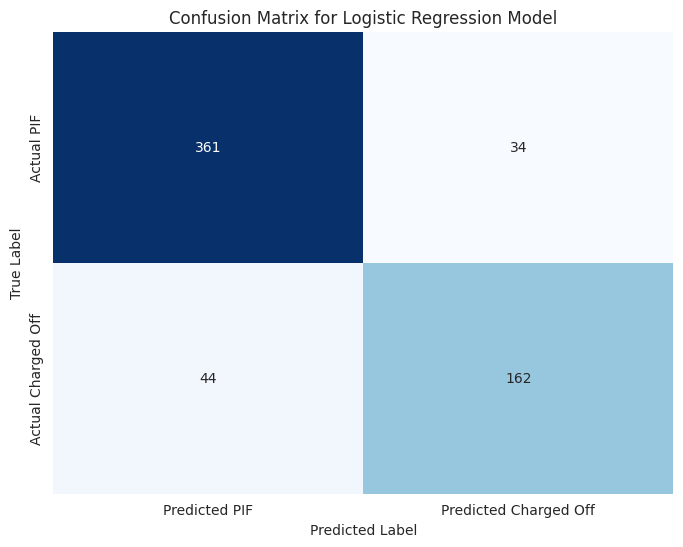

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare X_test with the same columns as the final trained model (lr_model8)
# Ensure 'const' is added to X_test for statsmodels prediction
x_test_final = sm.add_constant(X_test[x_train8.drop('const', axis=1).columns])

# Get predicted classes (0 or 1) using a threshold of 0.5
y_pred = (lr_model8.predict(x_test_final) >= 0.5).astype(int)

# Calculate the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
display(conf_matrix)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted PIF', 'Predicted Charged Off'],
            yticklabels=['Actual PIF', 'Actual Charged Off'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

 The model correctly predicted 523 out of 601 cases. It is particularly strong at identifying "Paid in Full" (PIF) loans, with 361 correct predictions and only 34 misses.



AUC Score: 0.8808


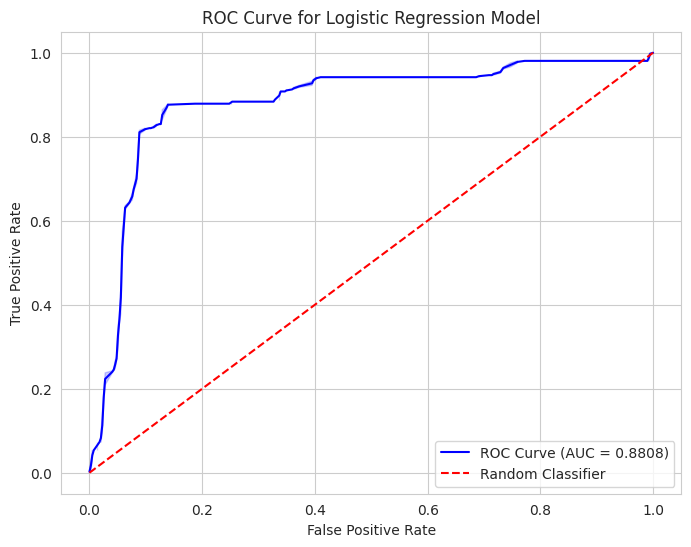

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# We need to make sure to add the constant to X_test for prediction using the statsmodels model

# Prepare X_test with the same columns as the final trained model (lr_model8)
x_test8 = sm.add_constant(X_test[x_train8.drop('const', axis=1).columns])

# Predict probabilities
y_pred_proba_sm_final_model = lr_model8.predict(x_test8)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba_sm_final_model)
print(f'AUC Score: {auc_score:.4f}')

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_sm_final_model)

# Plot ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='red', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.grid(True)
plt.show()

An AUC score of 0.8808  indicates that there is an 88% probability that the model will correctly rank a randomly chosen defaulted loan higher than a randomly chosen healthy loan.